In [268]:
from importlib import reload
import os
import sys
# Set up paths for utility imports
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')

os.chdir(current_dir)
# Ensure the utilities directory is in the import path
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
    
import plotting
import pinns
import numpy as np
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from pinns import  MLP, init_weights 
import sympy as sp
torch.set_default_dtype(torch.float64)

In [269]:
def pde_loss(
    model_u,
    model_k,
    X,
    F
):

    # --------------------------------------------------
    # Predictions
    # --------------------------------------------------

    u = model_u(X)
    k = model_k(X)
    #k = coefficient_torch(X)
    # --------------------------------------------------
    # grad(u)
    # --------------------------------------------------

    grad_u = torch.autograd.grad(
        u,
        X,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
    )[0]

    ux = grad_u[:, 0:1]
    uy = grad_u[:, 1:2]

    # --------------------------------------------------
    # Fluxes
    # --------------------------------------------------

    qx = k * ux
    qy = k * uy

    grad_qx = torch.autograd.grad(
        qx,
        X,
        grad_outputs=torch.ones_like(qx),
        create_graph=True,
    )[0]

    grad_qy = torch.autograd.grad(
        qy,
        X,
        grad_outputs=torch.ones_like(qy),
        create_graph=True,
    )[0]

    div = (
        grad_qx[:, 0:1]
        + grad_qy[:, 1:2]
    )

    residual = - div - F

    # --------------------------------------------------
    # PDE loss
    # --------------------------------------------------

    loss_pde = torch.mean(residual**2)
 
    return loss_pde

In [270]:
def observation_loss_u(
    model_u,
    X,
    U_true,
    criterion
):

    pred = model_u(X)

    mse = criterion(pred, U_true)

    return mse

In [271]:
def observation_loss_k(
    model_k,
    X,
    K_true,
    criterion
):

    pred = model_k(X)

    mse = criterion(pred, K_true)

    return mse

In [272]:
# --------------------------------------------------
# Parameters
# --------------------------------------------------

alpha = 0.5
beta = 5
epsilon = 1.0


# Symbolic variables
xs, ys = sp.symbols("x y")
alpha_s, beta_s = sp.symbols("alpha beta", positive=True)
eps_s = sp.symbols("epsilon", positive=True)

# -------------------------
# Manufactured solution
# Infinite domain
# -------------------------
u = sp.exp(
    -alpha_s*(xs**2 + ys**2)
) * sp.cos(beta_s*ys)

k = 1 + 2/(1 + sp.exp(-ys/eps_s))

# -------------------------
# Poisson source term
# -------------------------
ux = sp.diff(u, xs)
uy = sp.diff(u, ys)

f = -(
    sp.diff(k*ux, xs)
    +
    sp.diff(k*uy, ys)
)

f = sp.simplify(f)


f_numpy = sp.lambdify(
    (xs, ys, alpha_s, beta_s, eps_s),
    f,
    "numpy",
)

def source_term(x, y):
    return f_numpy(x, y, 0.5, 5, 1.0)
# --------------------------------------------------
# Analytical solution
# --------------------------------------------------

def analytical_solution(x, y, alpha=alpha, beta=beta):
    """
    Analytical solution u(x,y).
    """
    return np.exp(-alpha * (x**2 + y**2)) * np.cos(beta * y)

In [273]:
class CoefficientNet(nn.Module):

    def __init__(self,
                 hidden_layers=3,
                 hidden_units=25,
                 activation=nn.Tanh()):
        super().__init__()

        layers = [
            nn.Linear(1, hidden_units),
            activation
        ]

        for _ in range(hidden_layers-1):
            layers += [
                nn.Linear(hidden_units, hidden_units),
                activation
            ]

        layers.append(nn.Linear(hidden_units,1))

        self.net = nn.Sequential(*layers)

    def forward(self, X):

        y = X[:,1:2]

        phi = self.net(y)

        k = 1.0 + 2.0*torch.sigmoid(phi)

        return k

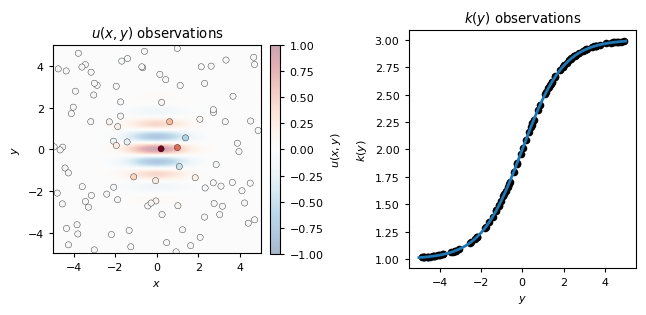


Training with Adam
Adam     0 | Total=5.329e+01 | ObsU=8.433e-01 | ObsK=7.210e-01 | PDE=5.172e+01

Adam   100 | Total=2.645e+01 | ObsU=1.152e-01 | ObsK=1.203e-01 | PDE=2.621e+01

Adam   200 | Total=9.175e+00 | ObsU=5.547e-01 | ObsK=1.597e-01 | PDE=8.461e+00

Adam   300 | Total=2.626e+00 | ObsU=1.176e-01 | ObsK=2.721e-01 | PDE=2.236e+00

Adam   400 | Total=1.871e+00 | ObsU=1.082e-01 | ObsK=2.838e-01 | PDE=1.479e+00

Adam   500 | Total=1.599e+00 | ObsU=4.818e-02 | ObsK=2.969e-01 | PDE=1.254e+00

Adam   600 | Total=1.258e+00 | ObsU=9.137e-03 | ObsK=3.422e-01 | PDE=9.065e-01

Adam   700 | Total=8.105e-01 | ObsU=1.027e-02 | ObsK=3.966e-01 | PDE=4.036e-01

Adam   800 | Total=6.974e-01 | ObsU=1.093e-02 | ObsK=3.988e-01 | PDE=2.877e-01

Adam   900 | Total=6.217e-01 | ObsU=8.236e-03 | ObsK=4.005e-01 | PDE=2.130e-01


Training with L-BFGS
L-BFGS   100 | Total=2.871e-01 | ObsU=7.014e-03 | ObsK=1.887e-01 | PDE=9.142e-02

L-BFGS   200 | Total=2.520e-02 | ObsU=9.186e-04 | ObsK=2.383e-03 | PDE=2.190

In [ ]:

# --------------------------------------------------
# Parameters
# --------------------------------------------------

alpha = 0.5
beta = 5
epsilon = 1.0


# Symbolic variables
xs, ys = sp.symbols("x y")
alpha_s, beta_s = sp.symbols("alpha beta", positive=True)
eps_s = sp.symbols("epsilon", positive=True)

# -------------------------
# Manufactured solution
# Infinite domain
# -------------------------
u = sp.exp(
    -alpha_s*(xs**2 + ys**2)
) * sp.cos(beta_s*ys)

k = 1 + 2/(1 + sp.exp(-ys/eps_s))

# -------------------------
# Poisson source term
# -------------------------
ux = sp.diff(u, xs)
uy = sp.diff(u, ys)

f = -(
    sp.diff(k*ux, xs)
    +
    sp.diff(k*uy, ys)
)

f = sp.simplify(f)


f_numpy = sp.lambdify(
    (xs, ys, alpha_s, beta_s, eps_s),
    f,
    "numpy",
)

def source_term(x, y):
    return f_numpy(x, y, 0.5, 5, 1.0)
# --------------------------------------------------
# Analytical solution
# --------------------------------------------------

def analytical_solution(x, y, alpha=alpha, beta=beta):
    """
    Analytical solution u(x,y).
    """
    return np.exp(-alpha * (x**2 + y**2)) * np.cos(beta * y)


def coefficient(x, y, epsilon=epsilon):
    """
    Variable coefficient k(y).
    """
    return 1 + 2 / (1 + np.exp(-y / epsilon))

results = []
iter_train = 0

adam_lr        = 1e-3
hidden_layers_ = 3
hidden_units_  = 25
 
adam_iters     = 1_000
lbfgs_iters    = 1_000
activation_function_ = nn.Tanh()
 
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model_u = MLP(
    input_size=2,
    output_size=1,
    hidden_layers=hidden_layers_,
    hidden_units=hidden_units_,
    activation_function=activation_function_,
).to(device).double()

model_u.apply(init_weights)

model_k = CoefficientNet(
    hidden_layers=3,
    hidden_units=25,
    activation=nn.Tanh(),
).to(device).double()

model_k.apply(init_weights)

np.random.seed(42)

N_obs_u = 100

x_obs = np.random.uniform(-5, 5, N_obs_u)
y_obs = np.random.uniform(-5, 5, N_obs_u)

N_obs_k = 100
x_obs_k = np.random.uniform(-5, 5, N_obs_k)
y_obs_k = np.random.uniform(-5, 5, N_obs_k)

u_obs = analytical_solution(x_obs, y_obs)
k_obs = coefficient(x_obs_k, y_obs_k)

# --------------------------------------------------
# PDE collocation points
# --------------------------------------------------

N_pde = 10_000

x_pde = np.random.uniform(-5, 5, N_pde)
y_pde = np.random.uniform(-5, 5, N_pde)

f_pde = source_term(x_pde, y_pde)

# Dense field for visualization
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)

X, Y = np.meshgrid(x, y)
U = analytical_solution(X, Y)

# --------------------------------------------------
# Observation tensors
# --------------------------------------------------

X_obs = torch.tensor(
    np.column_stack((x_obs, y_obs)),
    dtype=torch.float64,
    device=device,
)

X_obs_k = torch.tensor(
    np.column_stack((x_obs_k, y_obs_k)),
    dtype=torch.float64,
    device=device,
)

U_obs = torch.tensor(
    u_obs.reshape(-1,1),
    dtype=torch.float64,
    device=device,
)

K_obs = torch.tensor(
    k_obs.reshape(-1,1),
    dtype=torch.float64,
    device=device,
)

# --------------------------------------------------
# PDE tensors
# --------------------------------------------------

X_pde = torch.tensor(
    np.column_stack((x_pde, y_pde)),
    dtype=torch.float64,
    device=device,
    requires_grad=True,
)

F_pde = torch.tensor(
    f_pde.reshape(-1,1),
    dtype=torch.float64,
    device=device,
)

fig, ax = plt.subplots(
    1, 2,
    figsize=(6.8, 3.2),
)

# --------------------------------------------------
# Left: u(x,y)
# --------------------------------------------------
im1 = ax[0].imshow(
    U,
    extent=[-5, 5, -5, 5],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    alpha=0.35,
)

ax[0].scatter(
    x_obs,
    y_obs,
    c=u_obs,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    s=20,
    edgecolors="k",
    linewidths=0.25,
)

ax[0].set_title(r"$u(x,y)$ observations")
ax[0].set_xlabel(r"$x$")
ax[0].set_ylabel(r"$y$")
ax[0].set_aspect("equal")

cbar1 = fig.colorbar(
    im1,
    ax=ax[0],
    fraction=0.046,
    pad=0.04,
)
cbar1.set_label(r"$u(x,y)$")

# --------------------------------------------------
# Right: k(x,y)
# --------------------------------------------------
im2 = ax[1].imshow(
    K,
    extent=[-5, 5, -5, 5],
    origin="lower",
    cmap="GnBu",
    vmin=1,
    vmax=3,
    alpha=0.35,
)

ax[1].scatter(
    x_obs_k,
    y_obs_k,
    c=k_obs,
    cmap="GnBu",
    vmin=1,
    vmax=3,
    s=20,
    edgecolors="k",
    linewidths=0.25,
)

ax[1].set_title(r"$k(x,y)$ observations")
ax[1].set_xlabel(r"$x$")
ax[1].set_ylabel(r"$y$")
ax[1].set_aspect("equal")

cbar2 = fig.colorbar(
    im2,
    ax=ax[1],
    fraction=0.046,
    pad=0.04,
)
cbar2.set_label(r"$k(x,y)$")

plt.tight_layout()
plt.show()

# ============================================================
# Training data
# ============================================================

X_train = torch.tensor(
    np.column_stack((x_obs, y_obs)),
    dtype=torch.float64,
    device=device,
)

U_train = torch.tensor(
    u_obs.reshape(-1,1),
    dtype=torch.float64,
    device=device,
)

# ============================================================
# Training data
# ============================================================

X_train = torch.tensor(
    np.column_stack((x_obs, y_obs)),
    dtype=torch.float64,
    device=device,
)

U_train = torch.tensor(
    u_obs.reshape(-1,1),
    dtype=torch.float64,
    device=device,
)


# ------------------------------------------
# Boundary points for k(y)
# ------------------------------------------

X_k_bc = torch.tensor(
    [
        [0.0, -5.0],
        [0.0,  5.0],
    ],
    dtype=torch.float64,
    device=device,
)

K_bc = torch.tensor(
    coefficient(
        np.array([0.0, 0.0]),
        np.array([-5.0, 5.0]),
    ).reshape(-1,1),
    dtype=torch.float64,
    device=device,
)


def coefficient_boundary_loss(
    model_k,
    X_bc,
    K_bc,
    criterion,
):

    pred = model_k(X_bc)

    return criterion(pred, K_bc)

def train_dual_network(

    model_u,
    model_k,

    X_obs,
    U_obs,

    X_pde,
    F_pde,

    adam_lr=1e-3,
    adam_iters=1000,
    lbfgs_iters=2000,
    ):

    criterion = nn.MSELoss()

    # --------------------------------------------------------
    # Optimizers (parameters of both networks)
    # --------------------------------------------------------

    parameters = list(model_u.parameters()) + list(model_k.parameters())

    optimizer_adam = optim.Adam(
        parameters,
        lr=adam_lr,
    )

    optimizer_lbfgs = optim.LBFGS(
        parameters,
        lr=1.0,
        max_iter=lbfgs_iters,
        max_eval=lbfgs_iters,
        history_size=100,
        line_search_fn="strong_wolfe",
    )

    history = {
        "total": [],
        "u": [],
        "k": [],
        "pde": [],
        "grad_u": [],
        "grad_k": [],
        "grad_pde": [],
    }

    # ========================================================
    # Adam
    # ========================================================

    print("\n====================================")
    print("Training with Adam")
    print("====================================")

    model_u.train()
    model_k.train()

    for epoch in range(adam_iters):

        optimizer_adam.zero_grad()

        loss_u = observation_loss_u(
            model_u,
            X_obs,
            U_obs,
            criterion
        )
        loss_u = torch.nan_to_num(loss_u, nan=0.0)


        loss_k = observation_loss_k(
            model_k,
            X_obs_k,
            K_obs,
            criterion
        )

        loss_k = torch.nan_to_num(loss_k, nan=0.0)

        loss_pde = pde_loss(
            model_u,
            model_k,
            X_pde,
            F_pde
        )
        loss_pde = torch.nan_to_num(loss_pde, nan=0.0)
 

        loss = (
            loss_u
            + loss_k
            + loss_pde
        )

        loss.backward()

        optimizer_adam.step()

        history["total"].append(loss.item())
        history["u"].append(loss_u.item())
        history["k"].append(loss_k.item())
        history["pde"].append(loss_pde.item())


        if epoch % 100 == 0:

            print(
                f"Adam {epoch:5d} | "
                f"Total={loss.item():.3e} | "
                f"ObsU={loss_u.item():.3e} | "
                f"ObsK={loss_k.item():.3e} | "
                f"PDE={loss_pde.item():.3e}\n"
            )

    # ========================================================
    # L-BFGS
    # ========================================================

    print("\n====================================")
    print("Training with L-BFGS")
    print("====================================")

    state = {"iter": 0}

    def closure():

        optimizer_lbfgs.zero_grad()
 

        loss_u = observation_loss_u(
            model_u,
            X_obs,
            U_obs,
            criterion
        )
 

        loss_k = observation_loss_k(
            model_k,
            X_obs_k,
            K_obs,
            criterion
        )

        loss_pde = pde_loss(
            model_u,
            model_k,
            X_pde,
            F_pde
        )

        loss_u = torch.nan_to_num(loss_u, nan=0.0)
        loss_k = torch.nan_to_num(loss_k, nan=0.0)
        loss_pde = torch.nan_to_num(loss_pde, nan=0.0)

        loss = (
                loss_u
                + loss_k
                + loss_pde 
            )

        loss.backward()

    

        history["total"].append(loss.item())
        history["u"].append(loss_u.item())
        history["k"].append(loss_k.item())
        history["pde"].append(loss_pde.item())
 

        state["iter"] += 1

        if state["iter"] % 100 == 0:

            print(
                f"L-BFGS {state['iter']:5d} | "
                f"Total={loss.item():.3e} | "
                f"ObsU={loss_u.item():.3e} | "
                f"ObsK={loss_k.item():.3e} | "
                f"PDE={loss_pde.item():.3e}\n"
            )

        return loss

    optimizer_lbfgs.step(closure)

    return history

history = train_dual_network(

    model_u=model_u,
    model_k=model_k,

    X_obs=X_obs,
    U_obs=U_obs,

    X_pde=X_pde,
    F_pde=F_pde,

    adam_lr=adam_lr,
    adam_iters=adam_iters,
    lbfgs_iters=lbfgs_iters,
)

Relative L2 error (u): 5.149e-02
Relative L2 error (k): 2.359e-03


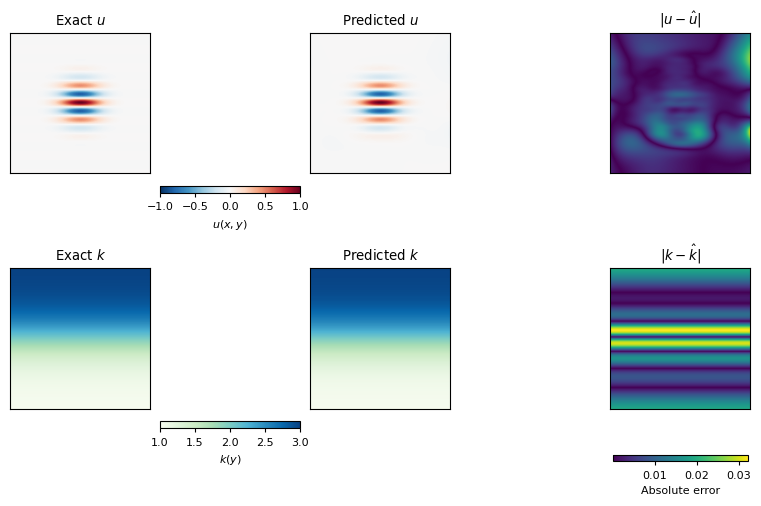

In [276]:
X_test = torch.tensor(
    np.column_stack((X.ravel(), Y.ravel())),
    dtype=torch.float64,
    device=device,
)

model_u.eval()
model_k.eval()

with torch.no_grad():

    U_pred = model_u(X_test)
    K_pred = model_k(X_test)

U_pred = U_pred.cpu().numpy().reshape(U.shape)
K_pred = K_pred.cpu().numpy().reshape(U.shape)

K_exact = coefficient(X, Y)

# ============================================================
# Relative errors
# ============================================================

err_u = np.linalg.norm(U_pred - U) / np.linalg.norm(U)
err_k = np.linalg.norm(K_pred - K_exact) / np.linalg.norm(K_exact)

print(f"Relative L2 error (u): {err_u:.3e}")
print(f"Relative L2 error (k): {err_k:.3e}")

# ============================================================
# Absolute errors
# ============================================================

error_u = np.abs(U_pred - U)
error_k = np.abs(K_pred - K_exact)

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    2,
    3,
    figsize=(9, 5),
    constrained_layout=True,
)

# ------------------------------------------------------------
# u(x,y)
# ------------------------------------------------------------

im = ax[0,0].imshow(
    U,
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)

ax[0,0].set_title("Exact $u$")
ax[0,0].set_xticks([])
ax[0,0].set_yticks([])

im = ax[0,1].imshow(
    U_pred,
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)

ax[0,1].set_title("Predicted $u$")
ax[0,1].set_xticks([])
ax[0,1].set_yticks([])

im = ax[0,2].imshow(
    error_u,
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="viridis",
)

ax[0,2].set_title(r"$|u-\hat u|$")
ax[0,2].set_xticks([])
ax[0,2].set_yticks([])

# ------------------------------------------------------------
# k(x,y)
# ------------------------------------------------------------

im = ax[1,0].imshow(
    K_exact,
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="GnBu",
    vmin=1,
    vmax=3,
)

ax[1,0].set_title("Exact $k$")
ax[1,0].set_xticks([])
ax[1,0].set_yticks([])

im = ax[1,1].imshow(
    K_pred,
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="GnBu",
    vmin=1,
    vmax=3,
)

ax[1,1].set_title("Predicted $k$")
ax[1,1].set_xticks([])
ax[1,1].set_yticks([])

im = ax[1,2].imshow(
    error_k,
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="viridis",
)

ax[1,2].set_title(r"$|k-\hat k|$")
ax[1,2].set_xticks([])
ax[1,2].set_yticks([])

# ------------------------------------------------------------
# Colorbars
# ------------------------------------------------------------

cbar1 = fig.colorbar(
    ax[0,1].images[0],
    ax=ax[0,:2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
)

cbar1.set_label(r"$u(x,y)$")

cbar2 = fig.colorbar(
    ax[1,1].images[0],
    ax=ax[1,:2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
)

cbar2.set_label(r"$k(y)$")

cbar3 = fig.colorbar(
    ax[0,2].images[0],
    ax=ax[:,2],
    orientation="horizontal",
    fraction=0.018,
    pad=0.12,
)

cbar3.set_label("Absolute error")

plt.show()